In [1]:
from optimization import *

c:\Users\frara\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [102]:
# creates the cfg for the SOGA model
compiledFile=compile2SOGA('../programs/SOGA/BNN/BNN.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

# initialize parameters
params = {'x1':  -0.25, 'x2': 1.25}
params_dict = initialize_params(params)  

# computes SOGA output
output_dist = start_SOGA(cfg, params_dict)
print(output_dist.gm.n_comp())

65536


In [103]:
def print_marg_par(dist, vars):
    idx_list = []

    for v in vars:
        idx_list.append(output_dist.var_list.index(v))

    return dist.gm.mean()[idx_list], dist.gm.cov()[idx_list, :][:, idx_list]


w_list = ['w1', 'w2', 'w3', 'w4']

prior_mean, prior_cov = print_marg_par(output_dist, w_list)

print('Last layer weights mean:', prior_mean)
print('Last layer weights covariance:', prior_cov)

Last layer weights mean: tensor([0., 0., 0., 0.], grad_fn=<IndexBackward0>)
Last layer weights covariance: tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]], grad_fn=<IndexBackward0>)


In [50]:
def f(x):
    return 0.7*math.sin(2*torch.pi*x)+0.3*x

y1, y2 = f(1.), f(0.)
trunc1 = 'y1=={}'.format(np.round(y1, 6))
trunc2 = 'y2=={}'.format(np.round(y2, 6))
print(trunc1, trunc2)

_, trunc_dist = truncate(output_dist, trunc1, {}, params_dict)
_, trunc_dist = truncate(trunc_dist, trunc2, {}, params_dict)


post_mean, post_cov = print_marg_par(trunc_dist, w_list)

print('Last layer weights mean:', post_mean)
print('Last layer weights covariance:', post_cov)

y1==0.3 y2==0.0
Last layer weights mean: tensor([ 0.0239,  0.0239,  0.0239, -0.0458], grad_fn=<IndexBackward0>)
Last layer weights covariance: tensor([[ 0.8029, -0.0583, -0.0583, -0.0581],
        [-0.0583,  0.8029, -0.0583, -0.0581],
        [-0.0583, -0.0583,  0.8029, -0.0581],
        [-0.0581, -0.0581, -0.0581,  0.7990]], grad_fn=<IndexBackward0>)


In [97]:
# creates the cfg for the SOGA model
compiledFile=compile2SOGA('../programs/SOGA/BNN/untrainedBNN.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

x_axis = np.linspace(-1, 2, 10)
untrained_y_axis = []

for xtest in x_axis:
    # initialize parameters
    params = {'x': xtest}
    params_dict = initialize_params(params)  

    # computes SOGA output
    output_dist = start_SOGA(cfg, params_dict)

    yidx = output_dist.var_list.index('y')
    untrained_y = output_dist.gm.mean()[yidx].detach()
    untrained_y_axis.append(untrained_y)


In [100]:
# creates the cfg for the SOGA model
compiledFile=compile2SOGA('../programs/SOGA/BNN/trainedBNN.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

x_axis = np.linspace(-1, 2, 10)
trained_y_axis = []

for xtest in x_axis:
    # initialize parameters
    params = {'x': xtest}
    params_dict = initialize_params(params)  

    # computes SOGA output
    output_dist = start_SOGA(cfg, params_dict)

    yidx = output_dist.var_list.index('y')
    trained_y = output_dist.gm.mean()[yidx].detach()
    trained_y_axis.append(trained_y)



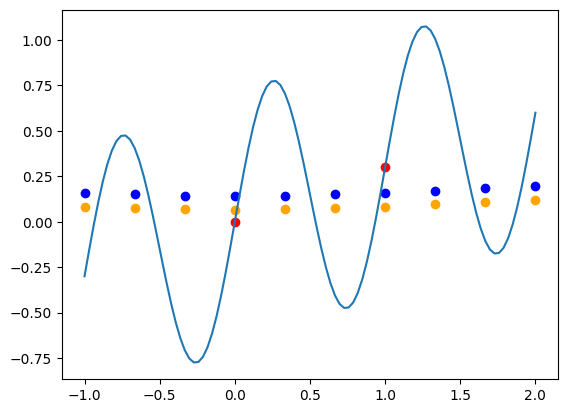

In [101]:
x = np.linspace(-1, 2, 100)
y = [f(xi) for xi in x]

import matplotlib.pyplot as plt

plt.plot(x, y)
plt.scatter([0., 1.], [y2, y1], marker='o', color='red')
#plt.scatter(0.5, f(0.5), marker='o', color='green')

plt.scatter(x_axis, untrained_y_axis, marker='o', color='orange')
plt.scatter(x_axis, trained_y_axis, marker='o', color='blue')



# Test

Devo controllare
1) che i momenti delle Gaussiane troncate siano calcolati correttamente
2) che i momenti della mistura siano calcolati correttamente
3) che i momenti della ReLU siano calcolati correttamente
4) che le somme di misture siano calcolate correttamente

In [24]:
# import module optimization to use DeGAS
from optimization import *
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)

def generate_mix_samples(p, mean1, cov1, mean2, cov2, n_samples):
    r = torch.rand(n_samples)
    samples = torch.zeros(n_samples, mean1.shape[1])
    for i in range(n_samples):
        if r[i] < p:
            samples[i] = torch.distributions.MultivariateNormal(mean1, cov1).rsample()
        else:
            samples[i] = torch.distributions.MultivariateNormal(mean2, cov2).rsample()
    return samples


In [46]:
text = """
x = gauss(0.33669035, 1);
a1 = -0.4869*x + 0.8815;
a2 = 0.5873*x - 0.7336;
if a1 > 0 {
    skip;
} else {
    a1 = 0;
} end if;
if a2 > 0 {
    skip;
} else {
    a2 = 0;
} end if;
y = 0.6146*a1 + 0.1323*a2 + 0.5224;
"""

compiledFile = compile2SOGA_text(text)
cfg = produce_cfg_text(compiledFile)
output_dist = start_SOGA(cfg, {})
yidx = output_dist.var_list.index('y')
print('y mean:', output_dist.gm.mean()[yidx])
print('y cov:', output_dist.gm.cov()[yidx, yidx])

y mean: tensor(0.9817)
y cov: tensor(0.0712)


### Moments of truncated Gaussians

In [21]:
dim = 3
torch.manual_seed(0)
mean = -1 + 2*torch.rand(1, dim)
cov = torch.rand(dim, dim)
cov = cov @ cov.T
mean, cov

(tensor([[ 0.9401,  0.4156, -0.0812]]),
 tensor([[1.8897, 0.8509, 0.6974],
         [0.8509, 0.4931, 0.3133],
         [0.6974, 0.3133, 0.3194]]))

In [22]:
norm = torch.distributions.MultivariateNormal(mean, cov)
n_samples = 100_000
samples = norm.rsample((100_000,)).squeeze(1)
trunc_samples = samples[samples[:, 0] > 0]

# Compute mean and covariance from trunc_samples
# trunc_samples: shape [N, 2]
mean_est = trunc_samples.mean(dim=0, keepdim=True)  # Shape: (1, 2)
cov_est = torch.cov(trunc_samples.T)  # Shape: (2, 2)

print('Prob estimate:', len(trunc_samples)/n_samples)
print('Mean estimate:', mean_est)
print('Covariance estimate:', cov_est)

Prob estimate: 0.75438
Mean estimate: tensor([[1.5168, 0.6749, 0.1328]])
Covariance estimate: tensor([[1.0191, 0.4590, 0.3748],
        [0.4590, 0.3161, 0.1684],
        [0.3748, 0.1684, 0.2004]])


In [23]:
dist = Dist(['x', 'y', 'z'], GaussianMix(torch.tensor([[1.]]), mean, cov.unsqueeze(0)))
truncate(dist, 'x>0', {}, {})

(tensor(0.7530),
 Dist<['x', 'y', 'z'],pi: tensor([[1.]])
 mu: tensor([[1.5166, 0.6752, 0.1315]])
 sigma: tensor([[[1.0155, 0.4572, 0.3747],
          [0.4572, 0.3159, 0.1680],
          [0.3747, 0.1680, 0.2004]]])>)

### Mixture Moments

In [26]:
dim = 3
torch.manual_seed(0)

mean1 = -1 + 2*torch.rand(1, dim)
cov1 = torch.rand(dim, dim)
cov1 = cov @ cov.T

mean2 = -1 + 2*torch.rand(1, dim)
cov2 = torch.rand(dim, dim)
cov2 = cov @ cov.T

p = torch.rand(1)

print(p, mean1, cov1, mean2, cov2)

tensor([0.2260]) tensor([[ 0.9401,  0.4156, -0.0812]]) tensor([[4.7814, 2.2459, 1.8072],
        [2.2459, 1.0653, 0.8479],
        [1.8072, 0.8479, 0.6865]]) tensor([[-0.2895,  0.2438, -0.0363]]) tensor([[4.7814, 2.2459, 1.8072],
        [2.2459, 1.0653, 0.8479],
        [1.8072, 0.8479, 0.6865]])


In [29]:

n_samples = 100_000
samples = generate_mix_samples(p, mean1, cov1, mean2, cov2, n_samples)

# Compute mean and covariance from trunc_samples
# trunc_samples: shape [N, 2]
mean_est = samples.mean(dim=0, keepdim=True)  # Shape: (1, 2)
cov_est = torch.cov(samples.T)  # Shape: (2, 2)

print('Mean estimate:', mean_est)
print('Covariance estimate:', cov_est)

Mean estimate: tensor([[-0.0090,  0.2841, -0.0456]])
Covariance estimate: tensor([[5.0282, 2.2759, 1.7909],
        [2.2759, 1.0678, 0.8440],
        [1.7909, 0.8440, 0.6845]])


In [46]:
dist = Dist(['x', 'y', 'z'], GaussianMix(torch.tensor([p.item(), (1-p).item()]).reshape(-1,1), 
                                         torch.stack([mean1, mean2]).squeeze(1), 
                                         torch.stack([cov1, cov2])))

dist.gm.mean(), dist.gm.cov()

(tensor([-0.0116,  0.2826, -0.0465]),
 tensor([[5.0459, 2.2829, 1.7975],
         [2.2829, 1.0704, 0.8466],
         [1.7975, 0.8466, 0.6869]]))

### ReLU

In [12]:
dim = 1
torch.manual_seed(2)

mean = -1 + 2*torch.rand(1, dim)
cov = torch.rand(dim, dim)
cov = cov @ cov.T

print(mean, cov, torch.sqrt(cov))

tensor([[0.8351]]) tensor([[0.0094]]) tensor([[0.0969]])


In [13]:
norm = torch.distributions.MultivariateNormal(mean, cov)
n_samples = 100_000
samples = norm.rsample((100_000,)).squeeze(1)
trunc_samples = torch.stack([sample if sample[0] > 0 else torch.zeros_like(sample) for sample in samples])

# Compute mean and covariance from trunc_samples
# trunc_samples: shape [N, 2]
mean_est = trunc_samples.mean(dim=0, keepdim=True)  # Shape: (1, 2)
cov_est = torch.cov(trunc_samples.T)  # Shape: (2, 2)

print('Mean estimate:', mean_est)
print('Covariance estimate:', cov_est)

Mean estimate: tensor([[0.8354]])
Covariance estimate: tensor(0.0092)


In [14]:
dist = Dist(['x'], GaussianMix(torch.tensor([[1.]]), mean, cov.unsqueeze(0)))

pi1, dist1 = truncate(dist, 'x>0', {}, {})
mu1 = dist1.gm.mu
sigma1 = dist1.gm.sigma

pi2, _ = truncate(dist, 'x<=0', {}, {})

new_dist = Dist(['x', 'y', 'z'], GaussianMix(torch.tensor([pi1.item(), pi2.item()]).reshape(-1,1),
                                            torch.stack([mu1, torch.zeros_like(mu1)]).squeeze(1), 
                                            torch.stack([sigma1, torch.zeros_like(sigma1)]).squeeze(1)))


new_dist.gm.mean(), new_dist.gm.cov()

(tensor([0.8351]), tensor([[0.0094]]))

In [15]:
text = """
x = gauss(0.8351, 0.0969);
if x > 0 {
    skip;
} else {
    x = 0;
} end if;
"""

compiledFile = compile2SOGA_text(text)
cfg = produce_cfg_text(compiledFile)
output_dist = start_SOGA(cfg, {})

output_dist.gm.mean(), output_dist.gm.cov()

(tensor([0.8351]), tensor([[0.0094]]))

### Sum of Mixtures

In [42]:
dim = 1
torch.manual_seed(0)

mean1 = -1 + 2*torch.rand(1, dim)
cov1 = torch.rand(dim, dim)
cov1 = cov1 @ cov1.T

mean2 = -1 + 2*torch.rand(1, dim)
cov2 = torch.rand(dim, dim)
cov2 = cov2 @ cov2.T

p1 = torch.rand(1)

print('First Mixture:')
print(mean1, cov1, torch.sqrt(cov1))
print(mean2, cov2, torch.sqrt(cov2))
print(p)

dim = 1

mean3 = -1 + 2*torch.rand(1, dim)
cov3 = torch.rand(dim, dim)
cov3 = cov3 @ cov3.T

mean4 = -1 + 2*torch.rand(1, dim)
cov4 = torch.rand(dim, dim)
cov4 = cov4 @ cov4.T

p2 = torch.rand(1)

print('Second Mixture:')
print(mean3, cov3, torch.sqrt(cov3))
print(mean4, cov4, torch.sqrt(cov4))
print(p2)

First Mixture:
tensor([[0.9401]]) tensor([[0.5010]]) tensor([[0.7078]])
tensor([[-0.0812]]) tensor([[0.8478]]) tensor([[0.9207]])
tensor([0.6450])
Second Mixture:
tensor([[0.5823]]) tensor([[0.0319]]) tensor([[0.1786]])
tensor([[-0.2978]]) tensor([[0.3380]]) tensor([[0.5813]])
tensor([0.2882])


In [43]:
n_samples = 100_000
samples1 = generate_mix_samples(p1, mean1, cov1, mean2, cov2, n_samples)
samples2 = generate_mix_samples(p2, mean3, cov3, mean4, cov4, n_samples)
samples = samples1 + samples2
samples.shape

torch.Size([100000, 1])

In [44]:
# Compute mean and covariance from trunc_samples
# trunc_samples: shape [N, 2]
mean_est = samples.mean(dim=0, keepdim=True)  # Shape: (1, 2)
cov_est = torch.cov(samples.T)  # Shape: (2, 2)

print('Mean estimate:', mean_est)
print('Covariance estimate:', cov_est)

Mean estimate: tensor([[0.5337]])
Covariance estimate: tensor(1.2711)


In [45]:
text = """ x = gm([{}, {}], [{}, {}], [{}, {}]); \n""".format(p1.item(), (1-p1).item(), mean1.item(), mean2.item(), cov1.sqrt().item(), cov2.sqrt().item()) + """ 
            y = gm([{}, {}], [{}, {}], [{}, {}]); \n""".format(p2.item(), (1-p2).item(), mean3.item(), mean4.item(), cov3.sqrt().item(), cov4.sqrt().item()) + """
            z = x + y;"""

print(text)

compiledFile = compile2SOGA_text(text)
cfg = produce_cfg_text(compiledFile)
output_dist = start_SOGA(cfg, {})
output_dist.gm.mean(), output_dist.gm.cov()

 x = gm([0.6450241201227648, 0.3549758798772352], [0.9401060036131061, -0.08123411374509826], [0.707819864399788, 0.9207476841219603]); 
 
            y = gm([0.2882358921361502, 0.7117641078638498], [0.5822957843606074, -0.2977847512121432], [0.17860617520075095, 0.5813409198075745]); 

            z = x + y;


(tensor([ 0.5776, -0.0441,  0.5334]),
 tensor([[ 8.6295e-01, -1.2379e-18,  8.6295e-01],
         [ 0.0000e+00,  4.0864e-01,  4.0864e-01],
         [ 8.6295e-01,  4.0864e-01,  1.2716e+00]]))